In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.utils.data as data_utils
import numpy as np
import os
import torch
import torch.nn as nn
torch.backends.cudnn.enabled=False
import torch.optim as optim
from torch.utils.data import Dataset
import pickle
import joblib
from sklearn.metrics import mean_absolute_error 
from lifelines.utils import concordance_index
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import subprocess
from sklearn.cluster import KMeans
from lifelines.utils import concordance_index
import argparse

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="3"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


def create_cluster_weights(binary_y, y, categories, func):
    curr_cluster_weights = []

    for i in range(len(y)):
        if len(y[(categories == categories[i]) & (binary_y == 0)]) > 0:
            max_cluster_y = max(1, max(y[(categories == categories[i]) & (binary_y == 0)]))
        else:
            max_cluster_y = max(1, max(y[(categories == categories[i])]))
        if func == 'linear':
            curr_cluster_weights.append((y[i])/(max_cluster_y))
        elif func == 'poly':
            curr_cluster_weights.append((y[i]**5)/(max_cluster_y**5))
        elif func == 'exp':
            curr_cluster_weights.append(np.exp(y[i])/np.exp(max_cluster_y))
    
    return np.array(curr_cluster_weights)

class CurrDataset(Dataset):
    def __init__(self, name, data):
        super().__init__()
        self.name = name
        self.features = data['features']
        self.labels = data['labels']
        self.uci = data['uncensored_indicator']
        self.propensity = data['propensity']
        self.cluster_weight = data['cluster_weight']
        self.length = len(self.features)
        
    def __len__(self):
        """Return number of sequences."""
        return self.length

    def __getitem__(self, index):
        """Return sequence and label at index."""
        return self.features[index].float(), self.labels[index].long(), self.uci[index].long(), self.propensity[index],  self.cluster_weight[index]



class IPCW(nn.Module):
    def __init__(self, num_input, num_output, num_layers, hidden_size):
        super(IPCW, self).__init__()
        self.num_output = num_output
        if num_layers == 1:
            self.feature_extractor = nn.Sequential(
                nn.Linear(num_input, num_output)
            )
        elif num_layers == 2:
            self.feature_extractor = nn.Sequential(
                nn.Linear(num_input, hidden_size),
                nn.ReLU(),
                nn.Linear(hidden_size, num_output)
            )
        elif num_layers == 3:
            self.feature_extractor = nn.Sequential(
                nn.Linear(num_input, hidden_size),
                nn.ReLU(),
                nn.Linear(hidden_size, hidden_size),
                nn.ReLU(),
                nn.Linear(hidden_size, num_output)
            )
                
    def forward(self, x, event_times, event_indicator, propensity, cluster_weight, lambda_loss):
        logits = self.feature_extractor(x)
        
        predictions = F.softmax(logits, dim=1)
        
        loss = self.total_loss(logits, event_times, event_indicator)
        
        propensity = torch.clamp(propensity, 0.1, 0.9) 
        IPCW_loss = torch.dot(1/propensity[event_indicator == 1], loss[event_indicator == 1])
        cluster_loss = torch.dot(cluster_weight[event_indicator == 0], loss[event_indicator == 0])
        
        loss = (IPCW_loss*len(event_indicator[event_indicator == 1]) + lambda_loss*cluster_loss*len(event_indicator[event_indicator == 0]))/len(event_indicator)
        
        return torch.argmax(predictions, 1), loss
    
    def total_loss(self, logits, event_times, event_indicator):
        event_times = event_times.long()
        batch_size, num_times = logits.shape
        event_times = event_times.clamp(0, num_times - 1)
                
        predictions = F.softmax(logits, dim=1)
        log_probs = torch.log(predictions + 1e-8)

        event_loss = -log_probs[torch.arange(batch_size), event_times]
        event_loss = torch.nan_to_num(event_loss, nan=0.0)  # Replace NaNs with 0
        
        return event_loss
    
    

def randomly_perturb_clusters(c, perturb_frac):
    c = np.array(c)
    n = len(c)
    unique_clusters = np.unique(c)
    n_clusters = len(unique_clusters)

    n_perturb = int(np.floor(perturb_frac * n))
    indices_to_perturb = np.random.choice(n, size=n_perturb, replace=False)
    c_perturbed = c.copy()

    for idx in indices_to_perturb:
        current = c[idx]
        new_label = np.random.choice(unique_clusters[unique_clusters != current])
        c_perturbed[idx] = new_label

    return c_perturbed

cuda


In [2]:
COUNT = 0
suffix = 'COUNT%d'%(COUNT)

X_test = joblib.load('$CWITE_DATA_ROOT/onevar_data/X_test_%s.joblib'%suffix).reshape(-1, 1)
y_test = joblib.load('$CWITE_DATA_ROOT/onevar_data/y_test_%s.joblib'%suffix)
binary_y_test = joblib.load('$CWITE_DATA_ROOT/onevar_data/actual_binary_y_test%s.joblib'%suffix)

X_train = joblib.load('$CWITE_DATA_ROOT/onevar_data/X_train_%s.joblib'%suffix).reshape(-1, 1)
y_train = joblib.load('$CWITE_DATA_ROOT/onevar_data/y_train_%s.joblib'%suffix)
orig_y_train = joblib.load('$CWITE_DATA_ROOT/onevar_data/orig_y_train_%s.joblib'%suffix)
binary_y_train = joblib.load('$CWITE_DATA_ROOT/onevar_data/binary_y_train_%s.joblib'%suffix)

X_val = joblib.load('$CWITE_DATA_ROOT/onevar_data/X_val_%s.joblib'%suffix).reshape(-1, 1)
y_val = joblib.load('$CWITE_DATA_ROOT/onevar_data/y_val_%s.joblib'%suffix)
orig_y_val = joblib.load('$CWITE_DATA_ROOT/onevar_data/orig_y_val_%s.joblib'%suffix)
binary_y_val = joblib.load('$CWITE_DATA_ROOT/onevar_data/binary_y_val_%s.joblib'%suffix)

val_roc_scores = []
for currC in [1, 1e-2, 1e-4, 1e-6]:
    clf = LogisticRegression(random_state=0, C = currC).fit(X_train, binary_y_train)
    y_pred = clf.predict(X_val)
    val_roc_scores.append(roc_auc_score(binary_y_val, y_pred))

bestC = np.array([1, 1e-2, 1e-4, 1e-6])[np.argmax(val_roc_scores)]

best_clf = LogisticRegression(random_state=0, C = bestC).fit(X_train, binary_y_train)

propensity_train = best_clf.predict(X_train)
propensity_val = best_clf.predict(X_val)
propensity_test = best_clf.predict(X_test)

k_values = range(2, 50)

# Compute K-means clustering scores
inertia_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train)
    inertia_scores.append(kmeans.inertia_)  # Sum of squared distances


inertia_diff = np.diff(inertia_scores)  # First derivative
inertia_diff2 = np.diff(inertia_diff)  # Second derivative (rate of change of slope)
elbow_k = k_values[np.argmin(inertia_diff2) + 1]  # Adding 1 to match k-values indexing
print(inertia_diff, elbow_k)



print(suffix, 'AUROC propensity', roc_auc_score(binary_y_val, propensity_val))

f_num_layers = 3
f_hidden_size = 16
f_batch_size = 256
f_lr = 0.01
f_wd = 1e-6

dict_ = {}
cols = ['varttc_tte', 'noise', 'lambda', 'func', 'MAE', 'MAE lower', 'MAE upper']
for col in cols:
    dict_[col] = []



for noise_param in [0, 0.25, 0.5]:
    for f_lambda_loss in [0.1, 0.5, 1]:
        for f_func in ['linear', 'poly', 'exp']: 
            kmeans = KMeans(n_clusters=elbow_k, random_state = 42, n_init = 10)
            categories_train = kmeans.fit_predict(X_train)
            categories_val = kmeans.predict(X_val)
            categories_test = kmeans.predict(X_test)

            categories_train = randomly_perturb_clusters(categories_train, noise_param)
            train_cluster_weight = create_cluster_weights(binary_y_train, y_train, categories_train, f_func)
            
            categories_val = randomly_perturb_clusters(categories_val, noise_param)
            val_cluster_weight = create_cluster_weights(binary_y_val, y_val, categories_val, f_func)
            
            categories_test = randomly_perturb_clusters(categories_test, noise_param)
            test_cluster_weight = create_cluster_weights(binary_y_test, y_test, categories_test, f_func)

            vars_ttes = []
            vars_tobs = []
            for i in list(set(categories_val)):
                var_tte = np.var(orig_y_val[(categories_val == i) & (binary_y_val == 0)])
                var_tobs = np.var(y_val[(categories_val == i) & (binary_y_val == 0)])
                vars_ttes.append(var_tte)
                vars_tobs.append(var_tobs)

            dict_['varttc_tte'].append(np.mean(np.array(vars_tobs) - np.array(vars_ttes)))
            

            train_dataset = CurrDataset("train", {'features':torch.tensor(X_train), 'labels':torch.tensor(y_train), 'uncensored_indicator':torch.tensor(binary_y_train), 'propensity':torch.tensor(propensity_train), 'cluster_weight':torch.tensor(train_cluster_weight)})
            train_loader = data_utils.DataLoader(train_dataset,
                                                 batch_size=f_batch_size,
                                                 shuffle=True)


            val_dataset = CurrDataset("train", {'features':torch.tensor(X_val), 'labels':torch.tensor(y_val), 'uncensored_indicator':torch.tensor(binary_y_val), 'propensity':torch.tensor(propensity_val), 'cluster_weight':torch.tensor(val_cluster_weight)})
            val_loader = data_utils.DataLoader(val_dataset,
                                                 batch_size=f_batch_size,
                                                 shuffle=False)

            test_dataset = CurrDataset("train", {'features':torch.tensor(X_test), 'labels':torch.tensor(y_test), 'uncensored_indicator':torch.tensor(binary_y_test), 'propensity':torch.tensor(propensity_test), 'cluster_weight':torch.tensor(test_cluster_weight)})
            test_loader = data_utils.DataLoader(test_dataset,
                                                 batch_size=f_batch_size,
                                                 shuffle=False)


            prop = IPCW(X_train.shape[1], max(y_train), f_num_layers, f_hidden_size).to(device)
            optimizer = optim.Adam(prop.parameters(), lr=f_lr, weight_decay=f_wd)
            optimizer.zero_grad()

            val_losses = []

            stop = -1
            for epoch in range(500):
                for batch_idx, (data, label, uci, propensity, cluster_weight) in enumerate(train_loader):
                    optimizer.zero_grad()
                    data, label, uci, propensity, cluster_weight = data.to(device), label.to(device).float(), uci.to(device), propensity.to(device).float(), cluster_weight.to(device).float()    
                    _, loss = prop(data, label, uci, propensity, cluster_weight, f_lambda_loss)
                    loss.backward()
                    # step
                    optimizer.step()

                curr_val_losses = []
                for batch_idx, (data, label, uci, propensity, cluster_weight) in enumerate(val_loader):
                    optimizer.zero_grad()
                    data, label, uci, propensity, cluster_weight = data.to(device), label.to(device).float(), uci.to(device), propensity.to(device).float(), cluster_weight.to(device).float()    
                    output, loss = prop(data, label, uci, propensity, cluster_weight, f_lambda_loss)
                    curr_val_losses.append(loss.detach().cpu().numpy())
                val_losses.append(np.mean(curr_val_losses))
                torch.save(prop, '$CWITE_DATA_ROOT/onevar_models/proptest_epoch%d'%(epoch))


                if val_losses[-1] > min(val_losses):
                    stop += 1
                if val_losses[-1] == min(val_losses):
                    stop = 0
                if stop == 15:
                    break


            best_epoch = np.argmin(val_losses)
            prop = IPCW(X_train.shape[1], max(y_train), f_num_layers, f_hidden_size).to(device)
            prop = torch.load('$CWITE_DATA_ROOT/onevar_models/proptest_epoch%d'%(best_epoch))


            test_preds = []
            test_true = []
            for batch_idx, (data, label, uci, propensity, cluster_weight) in enumerate(test_loader):
                data, label, uci, propensity, cluster_weight = data.to(device), label.to(device).float(), uci.to(device), propensity.to(device).float(), cluster_weight.to(device).float()            
                output, _ = prop(data, label, uci, propensity, cluster_weight, f_lambda_loss)

                test_preds.extend(output.detach().cpu().numpy().reshape(-1))
                test_true.extend(label.detach().cpu().numpy().reshape(-1))

            boot = []
            for _ in range(1000):
                idxs = np.random.choice(len(test_preds), len(test_preds))
                boot.append(np.mean(np.abs(np.array(test_preds)[idxs] - np.array(test_true)[idxs])))
            boot.sort()
            print(noise_param, f_lambda_loss, f_func, noise_param)
            dict_['noise'].append(noise_param)
            dict_['lambda'].append(f_lambda_loss)
            dict_['func'].append(f_func)
            dict_['MAE'].append(boot[500])
            dict_['MAE lower'].append(boot[25])
            dict_['MAE upper'].append(boot[975])

[-1.29019021e+03 -4.41804717e+02 -2.07071712e+02 -1.20984386e+02
 -6.14072243e+01 -4.32672111e+01 -2.93351583e+01 -2.04301021e+01
 -1.62490092e+01 -1.28741772e+01 -7.49847108e+00 -7.42776909e+00
 -5.69635818e+00 -5.26468606e+00 -3.69070442e+00 -3.58164493e+00
 -2.69120366e+00 -2.29654682e+00 -1.88847334e+00 -1.98605842e+00
 -1.54051060e+00 -1.58236722e+00 -1.03301805e+00 -1.39614042e+00
 -9.42993562e-01 -7.71941310e-01 -5.79094235e-01 -7.57793747e-01
 -5.39404841e-01 -7.25417111e-01 -5.21879760e-01 -3.86409040e-01
 -5.28867321e-01 -3.16088956e-01 -4.78326727e-01 -1.90273958e-01
 -3.06349313e-01 -2.84919586e-01 -2.42497786e-01 -2.97698824e-01
 -2.58458214e-01 -3.00797669e-01 -1.09521896e-01 -2.38651193e-01
 -9.72652120e-02 -1.38621398e-01 -1.63893617e-01] 25
COUNT0 AUROC propensity 0.9536799965861752


<home>/venv/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3747: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
<home>/venv/lib/python3.8/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
<home>/venv/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


0 0.1 linear 0


<home>/venv/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3747: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
<home>/venv/lib/python3.8/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
<home>/venv/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


0 0.1 poly 0


...

0 1 linear 0


<home>/venv/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3747: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
<home>/venv/lib/python3.8/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
<home>/venv/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


0 1 poly 0


<home>/venv/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3747: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
<home>/venv/lib/python3.8/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
<home>/venv/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


0 1 exp 0
0.25 0.1 linear 0.25
0.25 0.1 poly 0.25
0.25 0.1 exp 0.25
0.25 0.5 linear 0.25
0.25 0.5 poly 0.25
0.25 0.5 exp 0.25
0.25 1 linear 0.25
0.25 1 poly 0.25
0.25 1 exp 0.25
0.5 0.1 linear 0.5
0.5 0.1 poly 0.5
0.5 0.1 exp 0.5
0.5 0.5 linear 0.5
0.5 0.5 poly 0.5
0.5 0.5 exp 0.5
0.5 1 linear 0.5
0.5 1 poly 0.5
0.5 1 exp 0.5


In [3]:
for method in ['icind', 'pcind', 'dhcind']:
    baseline = joblib.load('$CWITE_DATA_ROOT/onevar_test_preds/%s_y_test_pred_%s.joblib'%(method, suffix))
    print(np.mean(np.abs(baseline - y_test)))

4.857333333333333
5.066
5.911666666666667


In [14]:
import pandas as pd
df = pd.DataFrame(dict_)

In [15]:
df

,varttc_tte,noise,lambda,func,MAE,MAE lower,MAE upper
0,26.461296,0.00,0.1,linear,6.158000,5.913667,6.417333
1,26.461296,0.00,0.1,poly,4.911333,4.675667,5.159333
2,26.461296,0.00,0.1,exp,5.079667,4.803667,5.351333
3,26.461296,0.00,0.5,linear,2.242000,2.132333,2.367667
4,26.461296,0.00,0.5,poly,1.014667,0.973667,1.063000
5,26.461296,0.00,0.5,exp,1.253000,1.195333,1.313333
6,26.461296,0.00,1.0,linear,2.454333,2.358667,2.565333
7,26.461296,0.00,1.0,poly,1.158000,1.107667,1.212667
8,26.461296,0.00,1.0,exp,1.644333,1.562667,1.725667
9,-10.703263,0.25,0.1,linear,3.369333,3.213667,3.527000


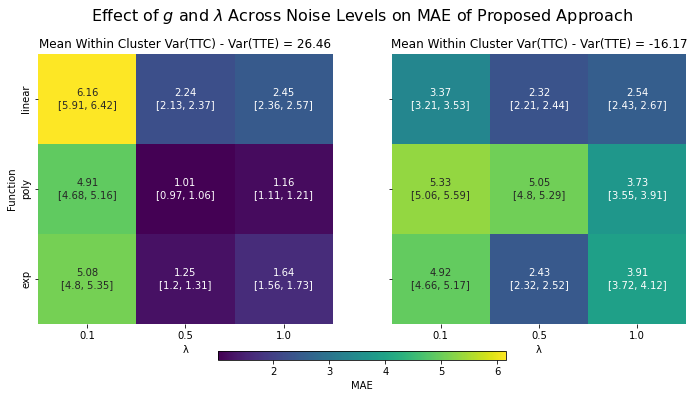

In [55]:
# Create figure and axes
import matplotlib.pyplot as plt
import seaborn as sns

df 

noise_levels = [0, 0.25]

vmin = df['MAE'].min()
vmax = df['MAE'].max()
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# Create the heatmaps
for i, noise in enumerate(noise_levels):
    
    desired_order = ['linear', 'poly', 'exp']  # <- customize this
    df['func'] = pd.Categorical(df['func'], categories=desired_order, ordered=True)

    subset = df[df['noise'] == noise].copy()
    pivot_mae = subset.pivot(index='func', columns='lambda', values='MAE')
    pivot_lower = subset.pivot(index='func', columns='lambda', values='MAE lower')
    pivot_upper = subset.pivot(index='func', columns='lambda', values='MAE upper')

    annot = (
        pivot_mae.round(2).astype(str)
        + "\n["
        + pivot_lower.round(2).astype(str)
        + ", "
        + pivot_upper.round(2).astype(str)
        + "]"
    )

    sns.heatmap(
        pivot_mae,
        annot=annot,
        fmt="",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        ax=axes[i],
        cbar=False
    )
    
    axes[i].set_title("Mean Within Cluster Var(TTC) - Var(TTE) = %0.2f"%subset['varttc_tte'].mean())
    axes[i].set_xlabel("λ")
    if i == 0:
        axes[i].set_ylabel("Function")
    else:
        axes[i].set_ylabel("")

# Add a ScalarMappable-based colorbar and place it lower on the figure
from matplotlib.cm import ScalarMappable
import matplotlib as mpl

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap="viridis")
sm.set_array([])

# Adjust colorbar position lower
cbar_ax = fig.add_axes([0.3, 0, 0.4, 0.025])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("MAE")

fig.suptitle("Effect of $g$ and $\\lambda$ Across Noise Levels on MAE of Proposed Approach", fontsize=16)

fig.subplots_adjust(left=0.05, right=0.95, top=0.85, bottom=0.1)  # Make sure bottom allows for colorbar
plt.savefig('hyperparameter_selection', bbox_inches='tight')


In [7]:
df

In [44]:
for method in ['icind', 'pcind', 'dhcind']:
    baseline = joblib.load('$CWITE_DATA_ROOT/onevar_test_preds/%s_y_test_pred_%s.joblib'%(method, suffix))
    print(np.mean(np.abs(baseline - y_test)))

4.857333333333333
5.066
5.911666666666667
